# 数据清洗 + EDA 探索性分析

本项目是「基于生存分析的用户流失预警」。

目标：
1. 从 MySQL 读取数据到 pandas
2. 数据质量检查（缺失值、异常值、数据类型）
3. 单变量/双变量分析，找到影响流失的关键因素
4. 可视化图表保存到 output/ 目录

## 0. 环境准备

运行这个 Cell 会自动定位项目根目录。后续所有路径（output/、data/、scripts/）都基于项目根。

In [15]:
import sys, os
from pathlib import Path

# ---- 自动定位项目根目录 ----
_cwd = Path(os.getcwd())
if (_cwd / 'scripts').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'scripts').exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path(r'C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis')

os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from db_config import get_sqlalchemy_url

sns.set_style('whitegrid')
# 设置中文字体：必须放在 seaborn set_style 之后，否则会被覆盖
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

print(f'项目根目录: {PROJECT_ROOT}')
print(f'当前工作目录: {os.getcwd()}')
print(f'scripts 存在: {(PROJECT_ROOT / "scripts").exists()}')
print(f'output 存在: {(PROJECT_ROOT / "output").exists()}')
print(f'data 存在: {(PROJECT_ROOT / "data").exists()}')
print('\n✅ 环境准备完成')

项目根目录: C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis
当前工作目录: C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis
scripts 存在: True
output 存在: True
data 存在: True

✅ 环境准备完成


## 1. 从 MySQL 读取数据

In [16]:
engine = create_engine(get_sqlalchemy_url())
df = pd.read_sql('SELECT * FROM telco_churn', con=engine)
print(f'数据形状:{df.shape}')
print(f'\n前5行:')
display(df.head())

数据形状:(7043, 21)

前5行:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


## 2. 数据质量检查

In [17]:
# 2.1 数据类型
print('数据类型:')
print(df.dtypes)

# 2.2 缺失值
print('\n缺失值统计:')
print(df.isnull().sum())

# 2.3 基础统计
print('\n数值型字段统计:')
display(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

数据类型:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

缺失值统计:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMet

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [18]:
# 2.4 异常值检查
print('异常值检查:')
print(f'tenure < 0 的行数: {(df["tenure"] < 0).sum()}')
print(f'MonthlyCharges < 0 的行数: {(df["MonthlyCharges"] < 0).sum()}')
print(f'TotalCharges < 0 的行数: {(df["TotalCharges"] < 0).sum()}')
print(f'tenure = 0 的行数: {(df["tenure"] == 0).sum()}')

print('\ntenure=0 的用户示例:')
display(df[df['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head())

异常值检查:
tenure < 0 的行数: 0
MonthlyCharges < 0 的行数: 0
TotalCharges < 0 的行数: 0
tenure = 0 的行数: 11

tenure=0 的用户示例:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
945,1371-DWPAZ,0,56.05,0.0,No
1731,2520-SGTTA,0,20.00,0.0,No
1906,2775-SEFEE,0,61.90,0.0,No
2025,2923-ARZLG,0,19.70,0.0,No
2176,3115-CZMZD,0,20.25,0.0,No


### 数据质量结论

记录一下数据质量情况：
- 是否有缺失值
- tenure=0 的用户有多少
- 有无异常值


## 3. 单变量分析

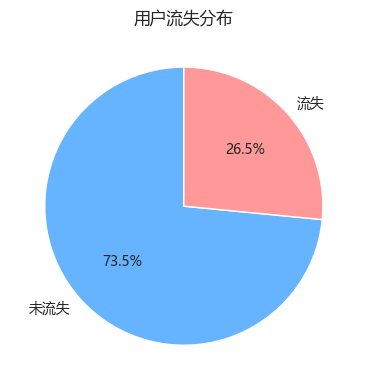

流失分布:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
流失率: 26.54%


In [19]:
# 3.1 流失分布
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
colors = ['#66b3ff', '#ff9999']
ax.pie(churn_counts, labels=['未流失', '流失'], autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('用户流失分布')
plt.tight_layout()
plt.savefig('output/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('流失分布:')
print(churn_counts)
print(f'流失率: {churn_counts["Yes"] / len(df) * 100:.2f}%')

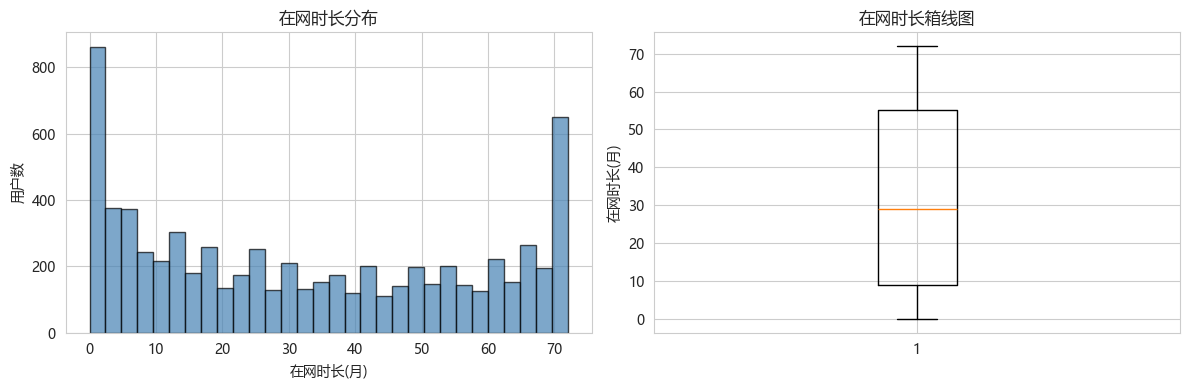

tenure 均值: 32.37
tenure 中位数: 29.00


In [20]:
# 3.2 在网时长 tenure 分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['tenure'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('在网时长(月)')
axes[0].set_ylabel('用户数')
axes[0].set_title('在网时长分布')
axes[1].boxplot(df['tenure'])
axes[1].set_ylabel('在网时长(月)')
axes[1].set_title('在网时长箱线图')
plt.tight_layout()
plt.savefig('output/02_tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'tenure 均值: {df["tenure"].mean():.2f}')
print(f'tenure 中位数: {df["tenure"].median():.2f}')

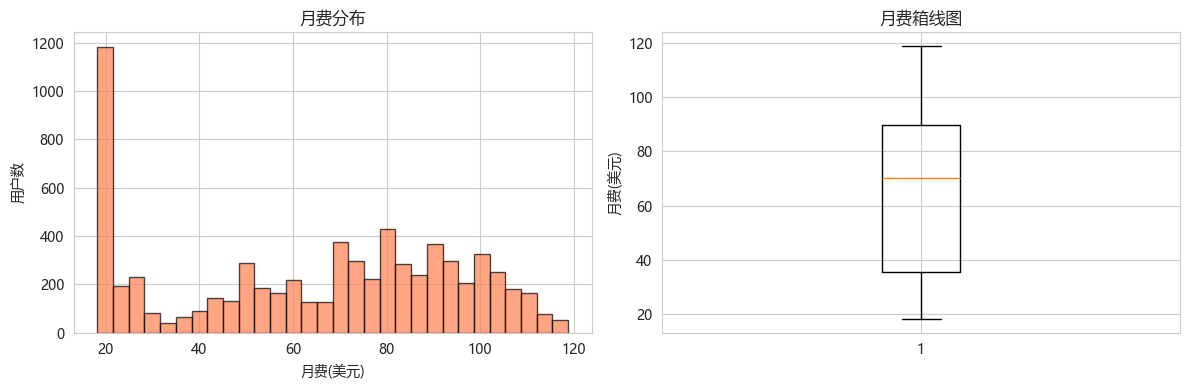

月费 均值: 64.76
月费 中位数: 70.35


In [21]:
# 3.3 月费 MonthlyCharges 分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['MonthlyCharges'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('月费(美元)')
axes[0].set_ylabel('用户数')
axes[0].set_title('月费分布')
axes[1].boxplot(df['MonthlyCharges'])
axes[1].set_ylabel('月费(美元)')
axes[1].set_title('月费箱线图')
plt.tight_layout()
plt.savefig('output/03_monthly_charges_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'月费 均值: {df["MonthlyCharges"].mean():.2f}')
print(f'月费 中位数: {df["MonthlyCharges"].median():.2f}')

## 4. 双变量分析：哪些因素影响流失

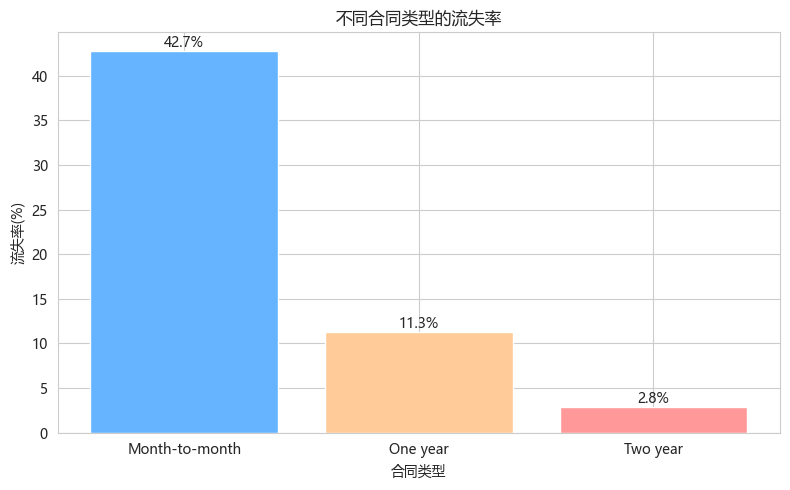

         Contract  ChurnRate
0  Month-to-month  42.709677
1        One year  11.269518
2        Two year   2.831858


In [32]:
# 4.1 合同类型 vs 流失率
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']
bars = ax.bar(contract_churn['Contract'], contract_churn['ChurnRate'], color=['#66b3ff', '#ffcc99', '#ff9999'])
ax.set_xlabel('合同类型')
ax.set_ylabel('流失率(%)')
ax.set_title('不同合同类型的流失率')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('output/04_contract_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
print(contract_churn)

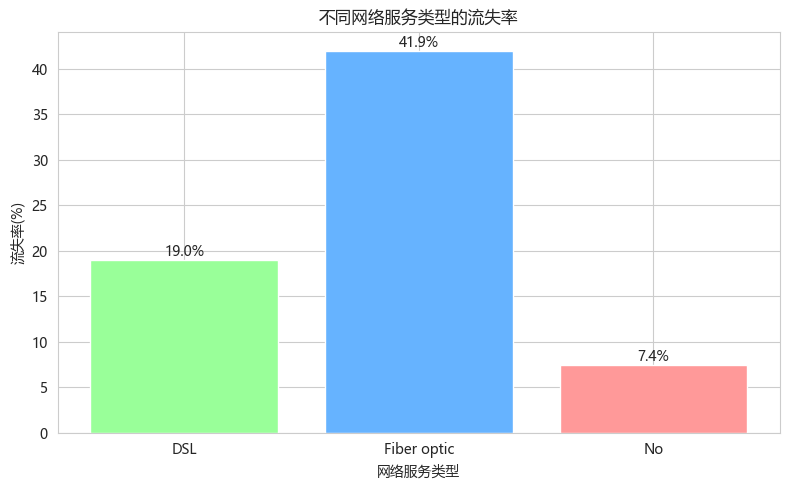

  InternetService  ChurnRate
0             DSL  18.959108
1     Fiber optic  41.892765
2              No   7.404980


In [33]:
# 4.2 网络服务类型 vs 流失率
fig, ax = plt.subplots(figsize=(8, 5))
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']
bars = ax.bar(internet_churn['InternetService'], internet_churn['ChurnRate'], color=['#99ff99', '#66b3ff', '#ff9999'])
ax.set_xlabel('网络服务类型')
ax.set_ylabel('流失率(%)')
ax.set_title('不同网络服务类型的流失率')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('output/05_internet_service_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
print(internet_churn)

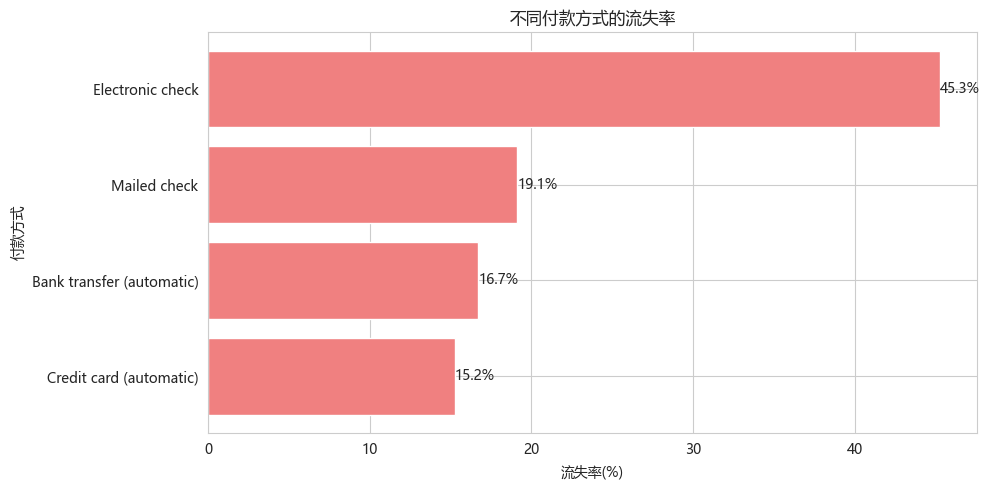

               PaymentMethod  ChurnRate
1    Credit card (automatic)  15.243101
0  Bank transfer (automatic)  16.709845
3               Mailed check  19.106700
2           Electronic check  45.285412


In [34]:
# 4.3 付款方式 vs 流失率
fig, ax = plt.subplots(figsize=(10, 5))
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
payment_churn.columns = ['PaymentMethod', 'ChurnRate']
payment_churn = payment_churn.sort_values('ChurnRate', ascending=True)
bars = ax.barh(payment_churn['PaymentMethod'], payment_churn['ChurnRate'], color='lightcoral')
ax.set_xlabel('流失率(%)')
ax.set_ylabel('付款方式')
ax.set_title('不同付款方式的流失率')
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'{width:.1f}%', ha='left', va='center')
plt.tight_layout()
plt.savefig('output/06_payment_method_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
print(payment_churn)

C:\Users\15854\AppData\Local\Temp\ipykernel_12032\2156395437.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()


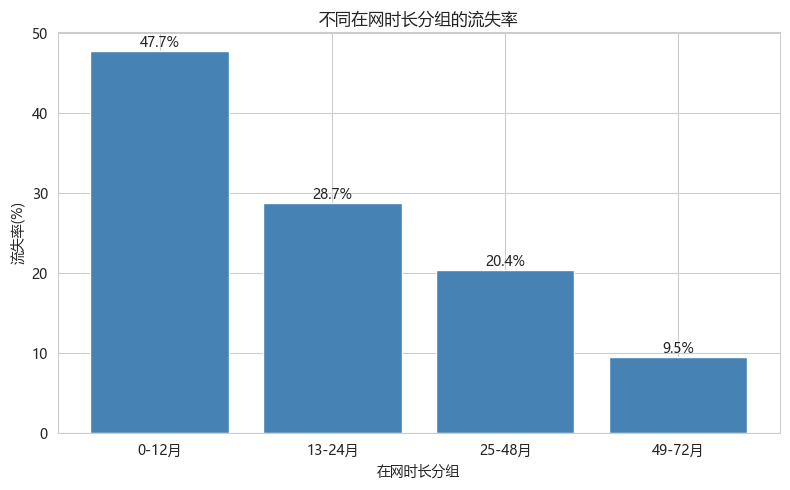

  tenure_group  ChurnRate
0        0-12月  47.678161
1       13-24月  28.710938
2       25-48月  20.388959
3       49-72月   9.513176


In [35]:
# 4.4 在网时长分箱 vs 流失率
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-12月', '13-24月', '25-48月', '49-72月'], right=True)
fig, ax = plt.subplots(figsize=(8, 5))
tenure_churn = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
tenure_churn.columns = ['tenure_group', 'ChurnRate']
bars = ax.bar(tenure_churn['tenure_group'].astype(str), tenure_churn['ChurnRate'], color='steelblue')
ax.set_xlabel('在网时长分组')
ax.set_ylabel('流失率(%)')
ax.set_title('不同在网时长分组的流失率')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('output/07_tenure_group_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
print(tenure_churn)

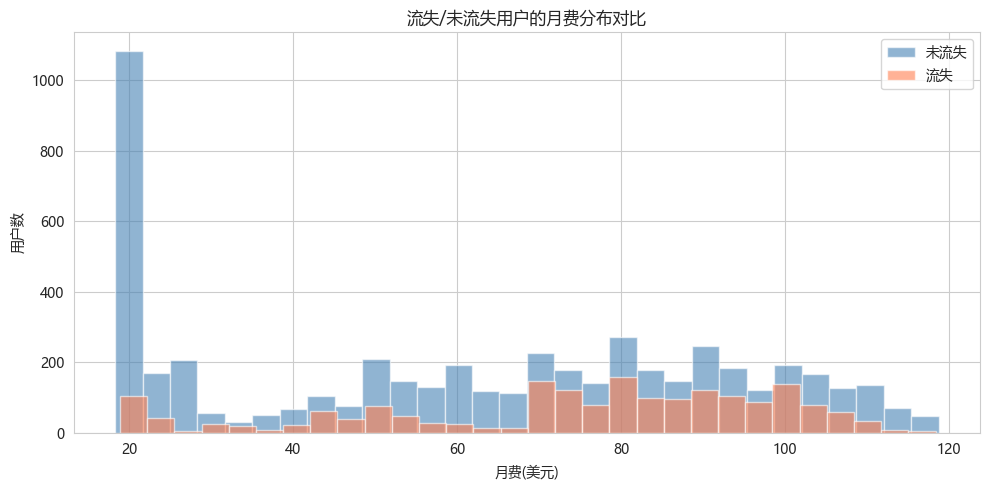

未流失用户月费均值: 61.26512369540008
流失用户月费均值: 74.44133226324237


In [36]:
# 4.5 月费 vs 流失关系
fig, ax = plt.subplots(figsize=(10, 5))
df[df['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.6, label='未流失', color='steelblue', ax=ax)
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.6, label='流失', color='coral', ax=ax)
ax.set_xlabel('月费(美元)')
ax.set_ylabel('用户数')
ax.set_title('流失/未流失用户的月费分布对比')
ax.legend()
plt.tight_layout()
plt.savefig('output/08_monthly_charges_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()
print('未流失用户月费均值:', df[df['Churn'] == 'No']['MonthlyCharges'].mean())
print('流失用户月费均值:', df[df['Churn'] == 'Yes']['MonthlyCharges'].mean())

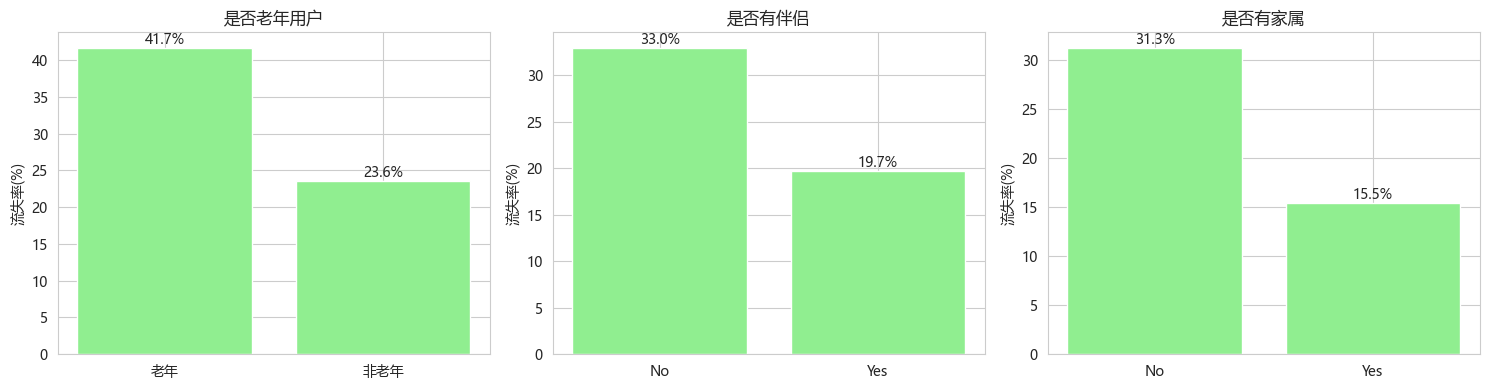

In [37]:
# 4.6 老年用户、伴侣、家属 vs 流失率
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ['SeniorCitizen', 'Partner', 'Dependents']
titles = ['是否老年用户', '是否有伴侣', '是否有家属']
for idx, col in enumerate(cols):
    if col == 'SeniorCitizen':
        temp_df = df.copy()
        temp_df[col] = temp_df[col].map({0: '非老年', 1: '老年'})
    else:
        temp_df = df.copy()
    group_churn = temp_df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    group_churn.columns = [col, 'ChurnRate']
    bars = axes[idx].bar(group_churn[col].astype(str), group_churn['ChurnRate'], color='lightgreen')
    axes[idx].set_ylabel('流失率(%)')
    axes[idx].set_title(titles[idx])
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('output/09_demographics_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. 关键发现总结

根据上面的分析，你应该能得出类似下面的结论（自己补充数据）：

1. **整体流失率**: 约 26.54%，每4个用户就流失1个
2. **合同类型是强影响因素**: 按月签约用户流失率最高，两年合同流失率最低
3. **网络服务**: Fiber optic 用户流失率明显高于 DSL 和无网络用户
4. **付款方式**: Electronic check 用户流失率最高
5. **在网时长**: 新用户(0-12月)流失率最高，老用户更稳定
6. **月费**: 流失用户平均月费高于未流失用户
7. **用户属性**: 老年用户、无伴侣、无家属的用户流失率更高

这些发现为后续的 Cox 回归模型提供了预期。

## 6. 保存清洗后的数据（可选）

In [ ]:
df.to_csv('data/telco_churn_cleaned.csv', index=False)
print('✅ 清洗后数据已保存到 data/telco_churn_cleaned.csv')